In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import statsmodels.api as sm
from datetime import timedelta
from src.analysis_visualization import simple_evaluate_single_ticker


In [46]:
# Coefficient Analysis 

coef_df = pd.read_csv('forecast_results/all_model_coefficients.csv')
try:
    # Load daily data
    with open("forecast_results/all_forecasts_daily.pkl", "rb") as f:
        daily_data = pickle.load(f)

    # Load hourly data  
    with open("forecast_results/all_forecasts_hourly.pkl", "rb") as f:
        hourly_data = pickle.load(f)

    # Load 5-minute data
    with open("forecast_results/all_forecasts_5min.pkl", "rb") as f:
        fivemin_data = pickle.load(f)

    print("✅ Data loaded successfully")

except FileNotFoundError as e:
    print(f"❌ Error loading pickle files: {e}")
    print("Make sure to run the notebook first to generate the forecast data!")
    exit(1)
except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit(1)

✅ Data loaded successfully


In [47]:
# Compute RMSE dictionary from loaded forecast data
# Adjusted to match simple_evaluate_single_ticker signature: (actuals, forecasts_dict)
# forecasts_dict should be {'GARCH': series, 'HAR': series, 'RFSV': series}

rmse_dict = {'daily': {}, 'hourly': {}, '5min': {}}

for freq in ['daily', 'hourly', '5min']:
    data_key = {'daily': daily_data, 'hourly': hourly_data, '5min': fivemin_data}[freq]
    actuals_key = {'daily': 'actuals_d', 'hourly': 'actuals_h', '5min': 'actuals_5m'}[freq]
    actuals = data_key[actuals_key]
    
    for ticker in data_key['tickers']:
        rmse_dict[freq][ticker] = {}
        forecasts_dict = {}
        
        # Build forecasts_dict based on available models for the frequency
        if freq == 'daily':
            if ticker in data_key.get('forecast_garch_d', {}):
                forecasts_dict['GARCH'] = data_key['forecast_garch_d'][ticker]
            if ticker in data_key.get('forecast_har_d', {}):
                forecasts_dict['HAR'] = data_key['forecast_har_d'][ticker]
            if ticker in data_key.get('forecast_rfsv_d', {}):
                forecasts_dict['RFSV'] = data_key['forecast_rfsv_d'][ticker]
        elif freq == 'hourly':
            if ticker in data_key.get('forecast_garch_h', {}):
                forecasts_dict['GARCH'] = data_key['forecast_garch_h'][ticker]
            if ticker in data_key.get('forecast_har_h', {}):
                forecasts_dict['HAR'] = data_key['forecast_har_h'][ticker]
            if ticker in data_key.get('forecast_rfsv_h', {}):
                forecasts_dict['RFSV'] = data_key['forecast_rfsv_h'][ticker]
        elif freq == '5min':
            # No GARCH for 5min
            if ticker in data_key.get('forecast_har_5m', {}):
                forecasts_dict['HAR'] = data_key['forecast_har_5m'][ticker]
            if ticker in data_key.get('forecast_rfsv_5m', {}):
                forecasts_dict['RFSV'] = data_key['forecast_rfsv_5m'][ticker]
        
        if forecasts_dict and ticker in actuals:
            try:
                results = simple_evaluate_single_ticker(actuals[ticker], forecasts_dict)
                for model in forecasts_dict.keys():
                    rmse_dict[freq][ticker][model] = results.loc[model, 'RMSE']
            except Exception as e:
                print(f"Error computing RMSE for {ticker} at {freq}: {e}")
                for model in forecasts_dict.keys():
                    rmse_dict[freq][ticker][model] = np.nan

print("✅ RMSE dictionary computed")

✅ RMSE dictionary computed


In [48]:
# Calculate average coefficients for each ticker-model-frequency combination
print("📊 Calculating average coefficients...")

# Group by Ticker, Model, Frequency, Param and calculate mean Value
avg_coef_df = coef_df.groupby(['Ticker', 'Model', 'Frequency', 'Param'])['Value'].mean().reset_index()
avg_coef_df.rename(columns={'Value': 'Avg_Value'}, inplace=True)

print(f"✅ Average coefficients calculated: {len(avg_coef_df)} records")

# Add RMSE to avg_coef_df using rmse_dict
avg_coef_df['RMSE'] = np.nan
for idx, row in avg_coef_df.iterrows():
    freq = row['Frequency']
    ticker = row['Ticker']
    model = row['Model']
    if ticker in rmse_dict[freq] and model in rmse_dict[freq][ticker]:
        avg_coef_df.at[idx, 'RMSE'] = rmse_dict[freq][ticker][model]

print(f"📊 avg_coef_df shape: {avg_coef_df.shape}")
print(f"📊 Sample avg_coef_df:\n{avg_coef_df.head()}")
print(f"✅ RMSE added to average coefficients (non-NaN count: {avg_coef_df['RMSE'].notna().sum()})")

📊 Calculating average coefficients...
✅ Average coefficients calculated: 270 records
📊 avg_coef_df shape: (270, 6)
📊 Sample avg_coef_df:
  Ticker  Model Frequency  Param  Avg_Value      RMSE
0   AAPL  GARCH     daily  alpha   0.106139  8.149652
1   AAPL  GARCH     daily   beta   0.818972  8.149652
2   AAPL  GARCH     daily  omega   0.292476  8.149652
3   AAPL  GARCH    hourly  alpha   0.017463  6.142693
4   AAPL  GARCH    hourly   beta   0.760162  6.142693
✅ RMSE added to average coefficients (non-NaN count: 270)


NameError: name 'col_name' is not defined

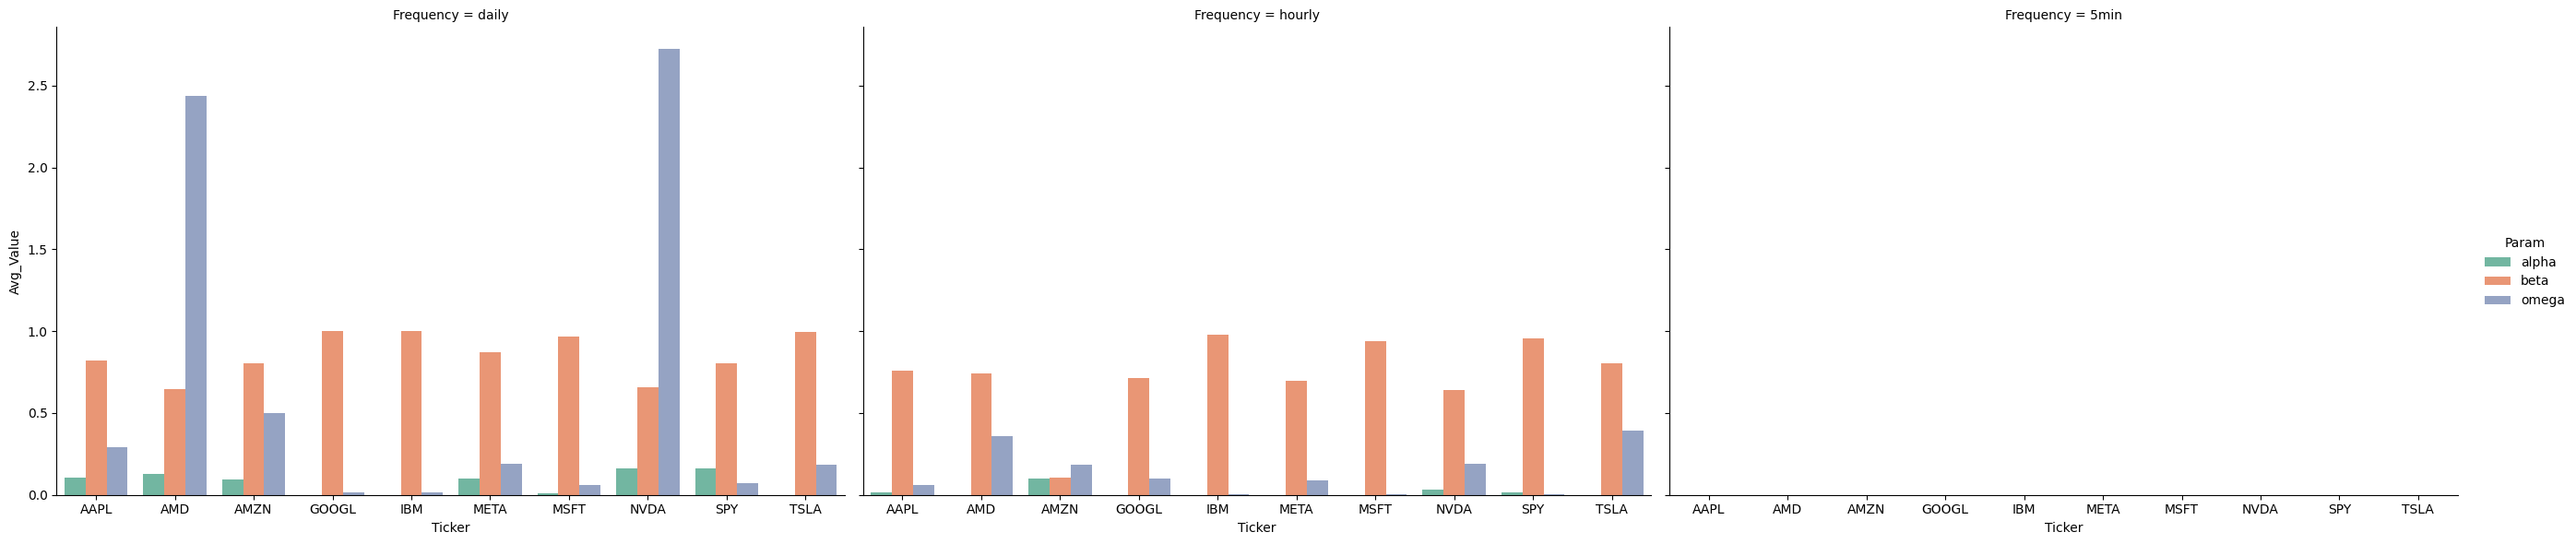

In [49]:
# Faceted bar plot: 1 plot per model with 3 subpanels for frequencies
# Each subpanel shows coefficients for 10 tickers, colored by param type
freq_order = ['daily', 'hourly', '5min']
ticker_order = sorted(avg_coef_df['Ticker'].unique())  # Sort tickers alphabetically

for model in ['GARCH', 'HAR', 'RFSV']:
    model_data = avg_coef_df[avg_coef_df['Model'] == model].dropna(subset=['Avg_Value'])
    
    if not model_data.empty:
        g = sns.catplot(
            data=model_data,
            x='Ticker',
            y='Avg_Value',
            hue='Param',
            col='Frequency',
            kind='bar',
            order=ticker_order,
            col_order=freq_order,
            col_wrap=3,  # 3 subpanels horizontally
            height=6,
            aspect=1.5,
            palette='Set2',  # Color palette for params
            legend=True
        )
        
        g.set_titles(f"{model} Model - {col_name} Frequency", fontsize=14, fontweight='bold')
        g.set_axis_labels("Ticker", "Average Coefficient Value", fontsize=12)
        g.set_xticklabels(rotation=45)
        g._legend.set_title("Parameter Type")
        plt.tight_layout()
        
        # Save plot
        plt.savefig(f'forecast_results/plots/multi_ticker/{model}_coefficients_barplot.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Faceted bar plot saved for {model} model")
    else:
        print(f"⚠️ No data available for {model} model")

print("✅ Faceted bar plots completed!")

In [ ]:
# Compute RFSV-specific table for H and nu parameters directly from raw coef_df
# For RFSV, coefficients are single values per ticker-frequency, so Mean = Value, SE = NaN

rfsv_raw = coef_df[(coef_df['Model'] == 'RFSV') & (coef_df['Param'].isin(['H', 'nu']))].copy()
rfsv_raw['Mean'] = rfsv_raw['Value']  # Single value as Mean
rfsv_raw['SE'] = np.nan  # SE not applicable for single estimate

# Pivot to wide format (only Mean for H and nu)
pivot_rfsv = rfsv_raw.pivot_table(
    index=['Ticker', 'Frequency'],
    columns='Param',
    values='Mean'
).reset_index()

# Drop rows with NaN values (in case some ticker-frequency missing H or nu)
pivot_rfsv = pivot_rfsv.dropna()

# Sort by Ticker and Frequency for better organization
pivot_rfsv = pivot_rfsv.sort_values(['Ticker', 'Frequency'])

# Flatten column names
pivot_rfsv.columns = ['_'.join(col).strip() if col[1] else col[0] for col in pivot_rfsv.columns]
pivot_rfsv.rename(columns={
    'Mean_H': 'H',
    'Mean_nu': 'nu'
}, inplace=True)

# Generate LaTeX table code (only H and nu)
latex_rfsv_table = r"""
\documentclass{article}
\usepackage{booktabs}
\usepackage{siunitx}
\usepackage{pdflscape}
\begin{document}

% Uncomment for landscape
% \begin{landscape}

\begin{table}[H]
\small
\centering
\caption{RFSV Model Parameters H and nu}
\label{tab:rfsv_coefficients}
\begin{tabular}{@{}p{1.5cm}p{1.5cm}S[table-format=1.4]S[table-format=1.4]@{}}
\toprule
{Ticker} & {Frequency} & {H} & {nu} \\
\midrule
"""

for _, row in pivot_rfsv.iterrows():
    latex_rfsv_table += f"{row['Ticker']} & {row['Frequency']} & {row['H']:.4f} & {row['nu']:.4f} \\\\\n"

latex_rfsv_table += r"""
\bottomrule
\end{tabular}
\end{table}

% \end{landscape}

\end{document}
"""

print("📊 RFSV LaTeX Table Code (copy to Overleaf):")
print(latex_rfsv_table)

# Save to file
with open('forecast_results/rfsv_coefficients_table.tex', 'w') as f:
    f.write(latex_rfsv_table)
print("✅ RFSV LaTeX table saved to forecast_results/rfsv_coefficients_table.tex")

IndexError: string index out of range